In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import pandas as pd
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
from matplotlib.patches import Rectangle, Patch
import matplotlib.lines as mlines
import matplotlib.patheffects as path_effects
import colormaps as cmaps
import matplotlib.colors as mcolors



In [2]:
# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------

rsl=xr.open_dataset("../../FesmData/Gowan2023_GAPSLIP_GrIS/output/rsl_dataset_reduced.nc")
gia=xr.open_dataset("../../FesmData/Schumacher2018_GIA_GrIS/data/schumacher2018_GR.nc")
topo = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")
vel = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_VEL-J18.nc")
iso=xr.open_dataset("../../FesmData/Leger2024_PaleoGris/output/paleogris_8km.nc")
bui = pd.read_excel("../../FesmData/Buizert2018/grl56971-sup-0002-supinfo.xlsx", header=10)
bui=bui.drop(0)
icec_id=["ngrip","grip","camp_century","dye3"]
icec=np.array([[75.0166666,72.5833,77.1667,65.1833326],[ -42.5333312,-37.6333,-61.1333,-43.8166634]])
rsl=xr.open_dataset("../../FesmData/Gowan2023_GAPSLIP_GrIS/output/rsl_dataset_reduced.nc")
f=25

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3824992/1298388012.py:7: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel("$\Delta T_{ann}$ (ºC)",fontsize=f)


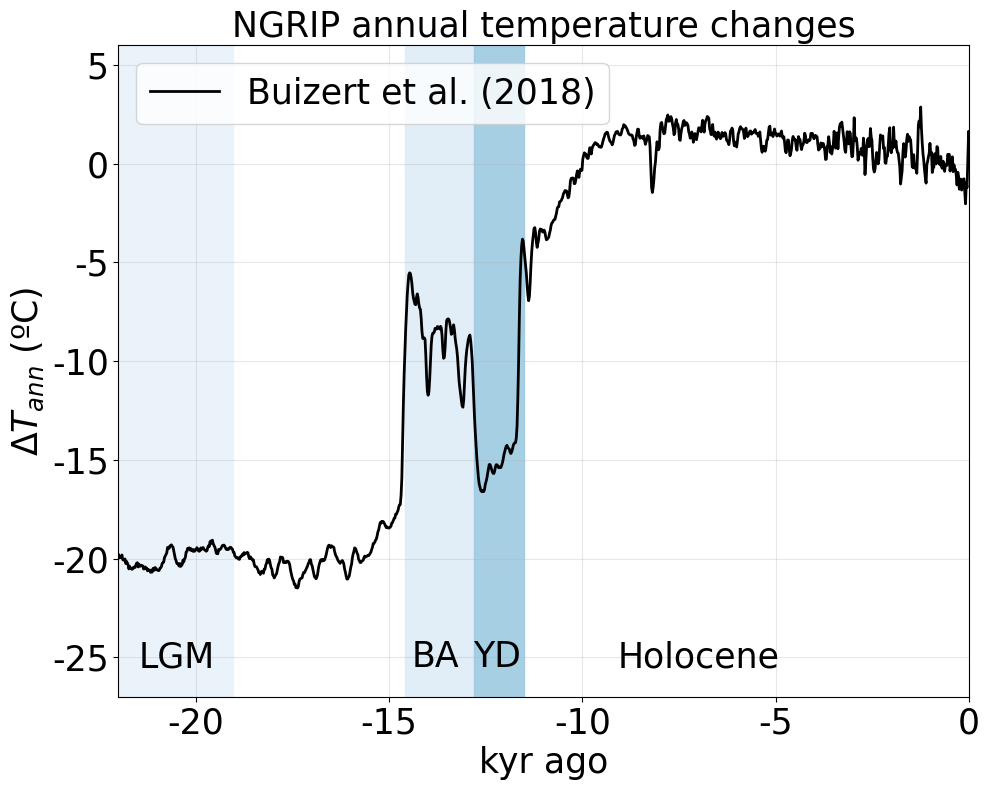

In [11]:

fig, ax = plt.subplots(1,1, figsize=(10,8))

ax.plot(-bui["NGRIP_Age "].values/1e3,bui["NGRIP_ANN"].values-bui["NGRIP_ANN"].values[1],color="black",linewidth=2, label="Buizert et al. (2018)")
ax.set_xlim(-22,0)
ax.set_ylim(-27,6)
ax.set_xlabel("kyr ago",fontsize=f)
ax.set_ylabel("$\Delta T_{ann}$ (ºC)",fontsize=f)

ax.axvspan(-22, -19, color="#deebf7", alpha=0.6)
ax.axvspan(-19, -14.8, color="white", alpha=0.8)   # azul claro
ax.axvspan(-14.6, -12.8, color="#deebf7", alpha=0.9)   # azul muy claro
ax.axvspan(-12.8, -11.5, color="#9ecae1", alpha=0.9)   # azul algo más oscuro

ax.text(-20.5, -25, "LGM", ha="center", va="center",fontsize=f)
ax.text(-13.8, -25, "BA",  ha="center", va="center",fontsize=f)
ax.text(-12.2, -25, "YD",  ha="center", va="center",fontsize=f)
ax.text(-7, -25, "Holocene",  ha="center", va="center",fontsize=f)

# ax.plot([-12, -0.2], [-19, -19], '-*k', markersize=10, clip_on=False)
# ax.text(-6, -17, "Surface elevations", ha="center", va="center")

# ax.plot([-14, -6.5], [2, 2], color="gray", linestyle="-", linewidth=1.5)
# ax.plot([-14, -6.5], [2, 2], color="gray", marker="|", markersize=12, linestyle="")
# ax.plot([-19, -16], [2, 2], color="gray", linestyle="-", linewidth=1.5)
# ax.plot([-19, -16], [2, 2], color="gray", marker="|", markersize=12, linestyle="")
# ax.text(-13, 4, "Margin reconstructions", ha="center", va="center", color="gray")
ax.tick_params(axis='both', labelsize=f)
datos_tiempo = np.array(rsl.time.where(rsl.time < 20000)).flatten()/(-1000)
datos_tiempo = datos_tiempo[~np.isnan(datos_tiempo)]
datos_tiempo_reduced = datos_tiempo[::24]
y_base = -10
plt.title("NGRIP annual temperature changes",fontsize=f)
ax.legend(loc="upper left",fontsize=f)
plt.tight_layout(h_pad=-0.2)
plt.grid(alpha=0.3)

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3824992/648923143.py:7: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel("$\Delta T_{ann}$ (ºC)",fontsize=f)


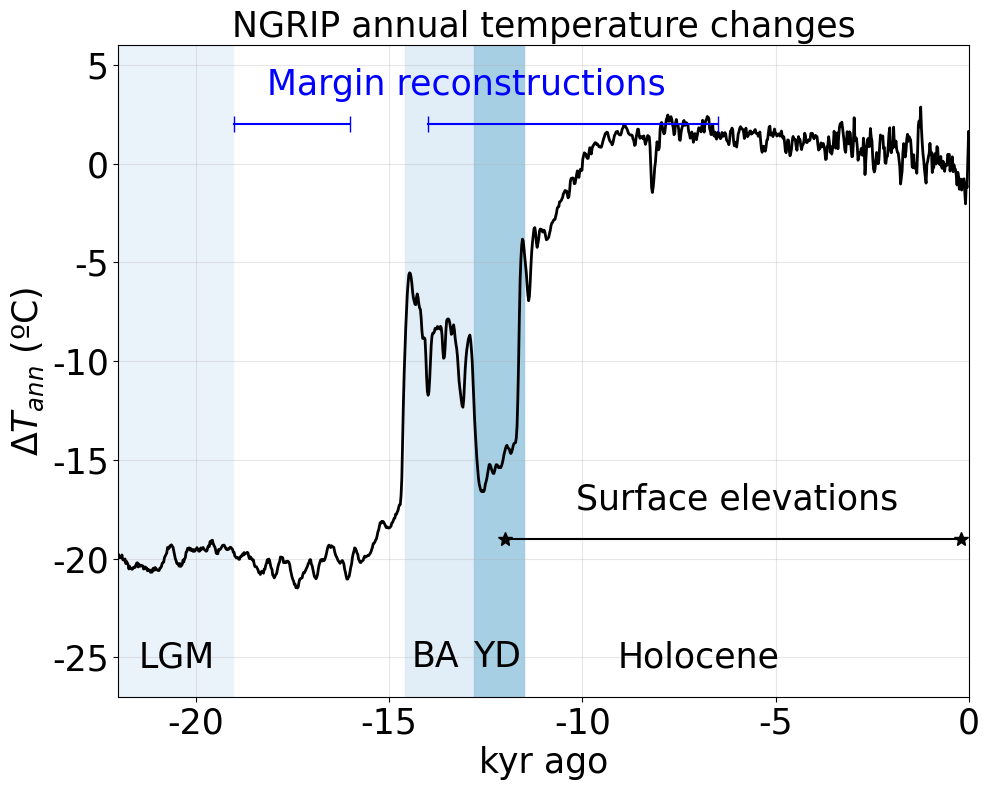

In [12]:

fig, ax = plt.subplots(1,1, figsize=(10,8))

ax.plot(-bui["NGRIP_Age "].values/1e3,bui["NGRIP_ANN"].values-bui["NGRIP_ANN"].values[1],color="black",linewidth=2, label="Buizert et al. (2018)")
ax.set_xlim(-22,0)
ax.set_ylim(-27,6)
ax.set_xlabel("kyr ago",fontsize=f)
ax.set_ylabel("$\Delta T_{ann}$ (ºC)",fontsize=f)

ax.axvspan(-22, -19, color="#deebf7", alpha=0.6)
ax.axvspan(-19, -14.8, color="white", alpha=0.8)   # azul claro
ax.axvspan(-14.6, -12.8, color="#deebf7", alpha=0.9)   # azul muy claro
ax.axvspan(-12.8, -11.5, color="#9ecae1", alpha=0.9)   # azul algo más oscuro

ax.text(-20.5, -25, "LGM", ha="center", va="center",fontsize=f)
ax.text(-13.8, -25, "BA",  ha="center", va="center",fontsize=f)
ax.text(-12.2, -25, "YD",  ha="center", va="center",fontsize=f)
ax.text(-7, -25, "Holocene",  ha="center", va="center",fontsize=f)

ax.plot([-12, -0.2], [-19, -19], '-*k', markersize=10, clip_on=False)
ax.text(-6, -17, "Surface elevations", ha="center", va="center",fontsize=f)

ax.plot([-14, -6.5], [2, 2], color="blue", linestyle="-", linewidth=1.5)
ax.plot([-14, -6.5], [2, 2], color="blue", marker="|", markersize=12, linestyle="")
ax.plot([-19, -16], [2, 2], color="blue", linestyle="-", linewidth=1.5)
ax.plot([-19, -16], [2, 2], color="blue", marker="|", markersize=12, linestyle="")
ax.text(-13, 4, "Margin reconstructions", ha="center", va="center", color="blue",fontsize=f)

datos_tiempo = np.array(rsl.time.where(rsl.time < 20000)).flatten()/(-1000)
datos_tiempo = datos_tiempo[~np.isnan(datos_tiempo)]
datos_tiempo_reduced = datos_tiempo[::24]
y_base = -10
ax.tick_params(axis='both', labelsize=f)

plt.title("NGRIP annual temperature changes",fontsize=f)
# ax.legend(loc="upper left",fontsize=f)
plt.tight_layout(h_pad=-0.2)
plt.grid(alpha=0.3)

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3824992/4221167577.py:7: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel("$\Delta T_{ann}$ (ºC)",fontsize=f)


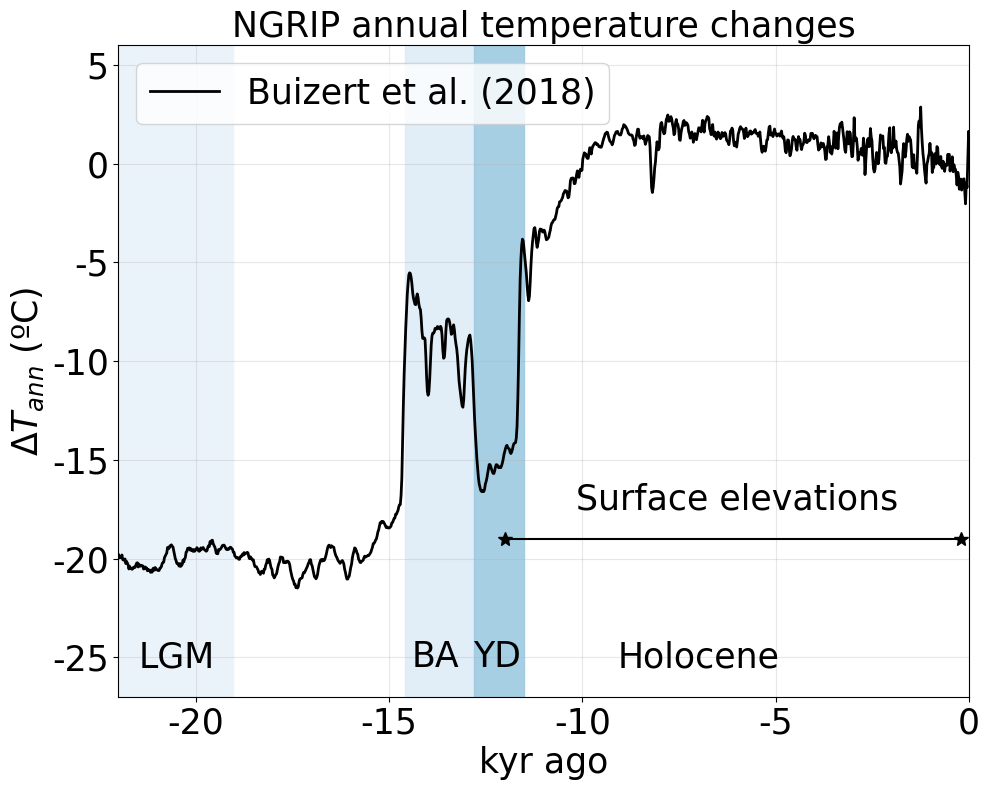

In [16]:

fig, ax = plt.subplots(1,1, figsize=(10,8))

ax.plot(-bui["NGRIP_Age "].values/1e3,bui["NGRIP_ANN"].values-bui["NGRIP_ANN"].values[1],color="black",linewidth=2, label="Buizert et al. (2018)")
ax.set_xlim(-22,0)
ax.set_ylim(-27,6)
ax.set_xlabel("kyr ago",fontsize=f)
ax.set_ylabel("$\Delta T_{ann}$ (ºC)",fontsize=f)

ax.axvspan(-22, -19, color="#deebf7", alpha=0.6)
ax.axvspan(-19, -14.8, color="white", alpha=0.8)   # azul claro
ax.axvspan(-14.6, -12.8, color="#deebf7", alpha=0.9)   # azul muy claro
ax.axvspan(-12.8, -11.5, color="#9ecae1", alpha=0.9)   # azul algo más oscuro

ax.text(-20.5, -25, "LGM", ha="center", va="center",fontsize=f)
ax.text(-13.8, -25, "BA",  ha="center", va="center",fontsize=f)
ax.text(-12.2, -25, "YD",  ha="center", va="center",fontsize=f)
ax.text(-7, -25, "Holocene",  ha="center", va="center",fontsize=f)

ax.plot([-12, -0.2], [-19, -19], '-*k', markersize=10, clip_on=False)
ax.text(-6, -17, "Surface elevations", ha="center", va="center",fontsize=f)

# ax.plot([-14, -6.5], [2, 2], color="blue", linestyle="-", linewidth=1.5)
# ax.plot([-14, -6.5], [2, 2], color="blue", marker="|", markersize=12, linestyle="")
# ax.plot([-19, -16], [2, 2], color="blue", linestyle="-", linewidth=1.5)
# ax.plot([-19, -16], [2, 2], color="blue", marker="|", markersize=12, linestyle="")
# ax.text(-13, 4, "Margin reconstructions", ha="center", va="center", color="blue")

datos_tiempo = np.array(rsl.time.where(rsl.time < 20000)).flatten()/(-1000)
datos_tiempo = datos_tiempo[~np.isnan(datos_tiempo)]
datos_tiempo_reduced = datos_tiempo[::24]
y_base = -10
ax.tick_params(axis='both', labelsize=f)

plt.title("NGRIP annual temperature changes",fontsize=f)
ax.legend(loc="upper left",fontsize=f)
plt.tight_layout(h_pad=-0.2)
plt.grid(alpha=0.3)

/tmp/ipykernel_30895/725627480.py:34: UserWarning: linewidths is ignored by contourf
  ax.contourf(lgm.xc, lgm.yc, mask, colors='red',  alpha=0.5, linewidths=1.5,zorder=5)


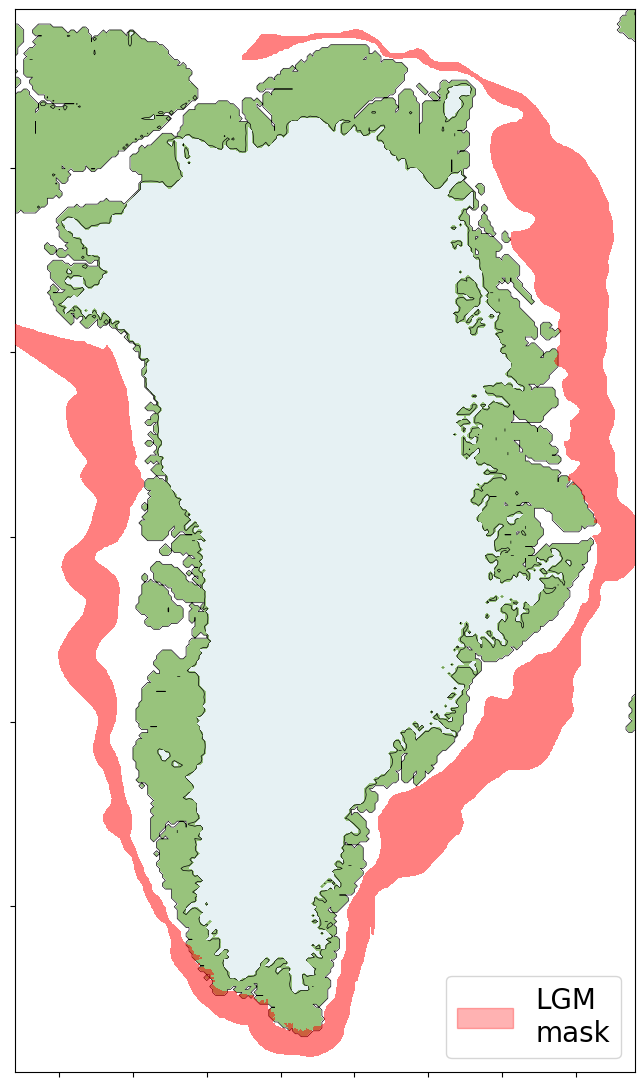

In [10]:
def add_map(ax, topo):
    lgm=xr.open_dataset("/p/projects/megarun/luciagu/data/leger2024/lgm.nc")
    lgm_leg = xr.where((lgm.mask==3),1,0)
    # Fondo: Morlinghem et al. 2017
    ax.set_facecolor("white")
    ax.contour(topo.xc, topo.yc, topo.z_srf, levels=np.linspace(0,10,1), colors="black", linewidths=0.5,zorder=3)
    ax.contourf(topo.xc, topo.yc, topo.z_srf.where(topo.z_srf>-10), colors="#98C37C",zorder=1)

    mask = np.where(np.isnan(topo.z_srf), 0, topo.z_srf)
    mask = np.where(mask == 0, 1, np.nan)
    
    ax.contourf(topo.xc, topo.yc, mask,colors="white",zorder=2)
    ax.contour(topo.xc, topo.yc, topo.H_ice, levels=np.linspace(100,110,1), colors="black", linewidths=0.5,zorder=3)
    ax.contourf(topo.xc, topo.yc, topo.H_ice.where(topo.H_ice>100), levels=np.linspace(0,4000,2), colors="#E6F1F3",zorder=3)

    # Ice core locations
    # for (lat,lon) in zip(icec[0,:], icec[1,:]):
    #     dist = np.sqrt((topo.lat2D - lat)**2 + (topo.lon2D - lon)**2)
    #     iy, ix = np.unravel_index(dist.argmin(), dist.shape)
    #     x = topo.xc[ix]
    #     y = topo.yc[iy]
    #     ax.plot(x, y, '*', color="black", markersize=10, markeredgecolor='black', zorder=6)  
    # ax.text(-450,-1290,"Camp Century", fontsize=12)
    # ax.text(0,-1595,"NGRIP", fontsize=12)
    # ax.text(150,-1830,"GRIP", fontsize=12)
    # ax.text(0,-2670,"DYE 3", fontsize=12)
    
    # Isochrones
    # plt.contourf(iso.xc,iso.yc,iso.age.where(iso.age>0), levels=np.linspace(0,14000,2),colors="gray", alpha=0.3, zorder=3)
    # plt.contour(iso.xc,iso.yc,iso.age.where(iso.age>0), levels=np.linspace(0,14000,2),colors="black", lineswidth=1,zorder=4)
    
    # lgm
    mask = lgm.mask.where(lgm.mask==3)
    ax.contourf(lgm.xc, lgm.yc, mask, colors='red',  alpha=0.5, linewidths=1.5,zorder=5)   
    gia_lab = mlines.Line2D([], [],color='red',marker='o',markersize=8,markerfacecolor='red',markeredgecolor='black',linestyle='none', label="GPS stations")
    rsl_lab = mlines.Line2D([], [],color='pink',marker='^',markersize=8,markerfacecolor='pink',markeredgecolor='black',linestyle='none',label="RSL")
    lgm_lab = mlines.Line2D([], [],color='red',markerfacecolor='red',linestyle='solid',alpha=0.5,label="max. LGM")
    iso_lab = Rectangle((0,0), 1, 1,facecolor='red',edgecolor='red',alpha=0.3,label='LGM\nmask')
    ax.legend(handles=[iso_lab], #iso_lab
                loc='lower right', facecolor="none",fontsize=20)
    ax.set_xlim(iso.xc.min(),iso.xc.max())
    ax.set_ylim(iso.yc.min(),iso.yc.max())
    ax.tick_params(labelbottom=False, labelleft=False)
    ax.set_aspect(1)
    return

fig,ax=plt.subplots(1,1, figsize=(8,14))
add_map(ax, topo)

/tmp/ipykernel_30895/1222556357.py:34: UserWarning: linewidths is ignored by contourf
  ax.contourf(lgm.xc, lgm.yc, mask, colors='red',  alpha=0.5, linewidths=1.5,zorder=5)


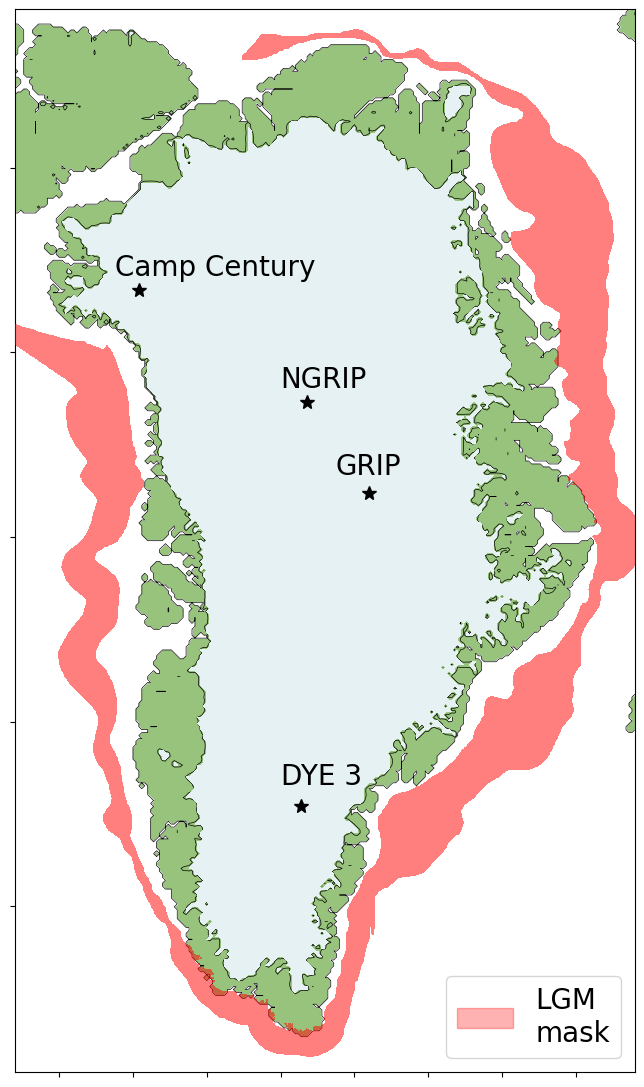

In [12]:
def add_map(ax, topo):
    lgm=xr.open_dataset("/p/projects/megarun/luciagu/data/leger2024/lgm.nc")
    lgm_leg = xr.where((lgm.mask==3),1,0)
    # Fondo: Morlinghem et al. 2017
    ax.set_facecolor("white")
    ax.contour(topo.xc, topo.yc, topo.z_srf, levels=np.linspace(0,10,1), colors="black", linewidths=0.5,zorder=3)
    ax.contourf(topo.xc, topo.yc, topo.z_srf.where(topo.z_srf>-10), colors="#98C37C",zorder=1)

    mask = np.where(np.isnan(topo.z_srf), 0, topo.z_srf)
    mask = np.where(mask == 0, 1, np.nan)
    
    ax.contourf(topo.xc, topo.yc, mask,colors="white",zorder=2)
    ax.contour(topo.xc, topo.yc, topo.H_ice, levels=np.linspace(100,110,1), colors="black", linewidths=0.5,zorder=3)
    ax.contourf(topo.xc, topo.yc, topo.H_ice.where(topo.H_ice>100), levels=np.linspace(0,4000,2), colors="#E6F1F3",zorder=3)

    # Ice core locations
    for (lat,lon) in zip(icec[0,:], icec[1,:]):
        dist = np.sqrt((topo.lat2D - lat)**2 + (topo.lon2D - lon)**2)
        iy, ix = np.unravel_index(dist.argmin(), dist.shape)
        x = topo.xc[ix]
        y = topo.yc[iy]
        ax.plot(x, y, '*', color="black", markersize=10, markeredgecolor='black', zorder=6)  
    ax.text(-450,-1290,"Camp Century", fontsize=20)
    ax.text(0,-1595,"NGRIP", fontsize=20)
    ax.text(150,-1830,"GRIP", fontsize=20)
    ax.text(0,-2670,"DYE 3", fontsize=20)
    
    # Isochrones
    # plt.contourf(iso.xc,iso.yc,iso.age.where(iso.age>0), levels=np.linspace(0,14000,2),colors="gray", alpha=0.3, zorder=3)
    # plt.contour(iso.xc,iso.yc,iso.age.where(iso.age>0), levels=np.linspace(0,14000,2),colors="black", lineswidth=1,zorder=4)
    
    # lgm
    mask = lgm.mask.where(lgm.mask==3)
    ax.contourf(lgm.xc, lgm.yc, mask, colors='red',  alpha=0.5, linewidths=1.5,zorder=5)   
    gia_lab = mlines.Line2D([], [],color='red',marker='o',markersize=8,markerfacecolor='red',markeredgecolor='black',linestyle='none', label="GPS stations")
    rsl_lab = mlines.Line2D([], [],color='pink',marker='^',markersize=8,markerfacecolor='pink',markeredgecolor='black',linestyle='none',label="RSL")
    lgm_lab = mlines.Line2D([], [],color='red',markerfacecolor='red',linestyle='solid',alpha=0.5,label="max. LGM")
    iso_lab = Rectangle((0,0), 1, 1,facecolor='red',edgecolor='red',alpha=0.3,label='LGM\nmask')
    ax.legend(handles=[iso_lab], #iso_lab
                loc='lower right', facecolor="none",fontsize=20)
    ax.set_xlim(iso.xc.min(),iso.xc.max())
    ax.set_ylim(iso.yc.min(),iso.yc.max())
    ax.tick_params(labelbottom=False, labelleft=False)
    ax.set_aspect(1)
    return

fig,ax=plt.subplots(1,1, figsize=(8,14))
add_map(ax, topo)

In [8]:
def add_map(ax, topo, gia, iso, rsl):
    lgm=xr.open_dataset("/p/projects/megarun/luciagu/data/leger2024/lgm.nc")
    lgm_leg = xr.where((lgm.mask==3)|(lgm.mask==2),1,0)
    # Fondo: Morlinghem et al. 2017
    ax.set_facecolor("white")
    ax.contour(topo.xc, topo.yc, topo.z_srf, levels=np.linspace(0,10,1), colors="black", linewidths=0.5,zorder=3)
    ax.contourf(topo.xc, topo.yc, topo.z_srf.where(topo.z_srf>-10), colors="#98C37C",zorder=1)

    mask = np.where(np.isnan(topo.z_srf), 0, topo.z_srf)
    mask = np.where(mask == 0, 1, np.nan)
    
    ax.contourf(topo.xc, topo.yc, mask,colors="white",zorder=2)
    ax.contour(topo.xc, topo.yc, topo.H_ice, levels=np.linspace(100,110,1), colors="black", linewidths=0.5,zorder=3)
    ax.contourf(topo.xc, topo.yc, topo.H_ice.where(topo.H_ice>100), levels=np.linspace(0,4000,2), colors="#E6F1F3",zorder=3)

    # RSL data points
    # for r_idx, reg in enumerate(rsl.region):
    #     sim = rsl.sel(region = reg)
    #     x, y = sim.xc.values, sim.yc.values
    #     ax.plot(x, y, '^',markersize=10,markeredgecolor='black',markerfacecolor="pink", zorder=4)
    
    # GIA
    # for station in gia.station.values:
    #     sim=gia.sel(station=station)
    #     ax.plot(sim.xc, sim.yc, 'o', color="red", markersize=7, markeredgecolor='black', zorder=6)  
    
    # Ice core locations
    for (lat,lon) in zip(icec[0,:], icec[1,:]):
        dist = np.sqrt((topo.lat2D - lat)**2 + (topo.lon2D - lon)**2)
        iy, ix = np.unravel_index(dist.argmin(), dist.shape)
        x = topo.xc[ix]
        y = topo.yc[iy]
        ax.plot(x, y, '*', color="black", markersize=10, markeredgecolor='black', zorder=6)  
    ax.text(-450,-1290,"Camp Century", fontsize=12)
    ax.text(0,-1595,"NGRIP", fontsize=12)
    ax.text(150,-1830,"GRIP", fontsize=12)
    ax.text(0,-2670,"DYE 3", fontsize=12)
    
    # Isochrones
    plt.contourf(iso.xc,iso.yc,iso.age.where(iso.age>0), levels=np.linspace(0,14000,2),colors="gray", alpha=0.3, zorder=3)
    plt.contour(iso.xc,iso.yc,iso.age.where(iso.age>0), levels=np.linspace(0,14000,2),colors="black", lineswidth=1,zorder=4)
    
    # lgm
    im_lgm=ax.contour(lgm.xc, lgm.yc, lgm_leg, colors='gray',  alpha=0.1, linewidths=1.5)
    # Legend
    gia_lab = mlines.Line2D([], [],color='red',marker='o',markersize=8,markerfacecolor='red',markeredgecolor='black',linestyle='none', label="GPS stations")
    rsl_lab = mlines.Line2D([], [],color='pink',marker='^',markersize=8,markerfacecolor='pink',markeredgecolor='black',linestyle='none',label="RSL")
    lgm_lab = mlines.Line2D([], [],color='gray',markerfacecolor='gray',linestyle='solid',alpha=0.5,label="max. LGM")
    iso_lab = Rectangle((0,0), 1, 1,facecolor='gray',edgecolor='black',alpha=0.3,label='PaleoGrIS\nisochrones')
    ax.legend(handles=[iso_lab,lgm_lab],
                loc='lower right')
    ax.set_xlim(iso.xc.min(),iso.xc.max())
    ax.set_ylim(iso.yc.min(),iso.yc.max())
    ax.tick_params(labelbottom=False, labelleft=False)
    ax.set_aspect(1)
    return


<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1974007/1454866632.py:8: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel("$\Delta T_{ann}$ (ºC)")
/tmp/ipykernel_1974007/3843984450.py:41: UserWarning: The following kwargs were not used by contour: 'lineswidth'
  plt.contour(iso.xc,iso.yc,iso.age.where(iso.age>0), levels=np.linspace(0,14000,2),colors="black", lineswidth=1,zorder=4)


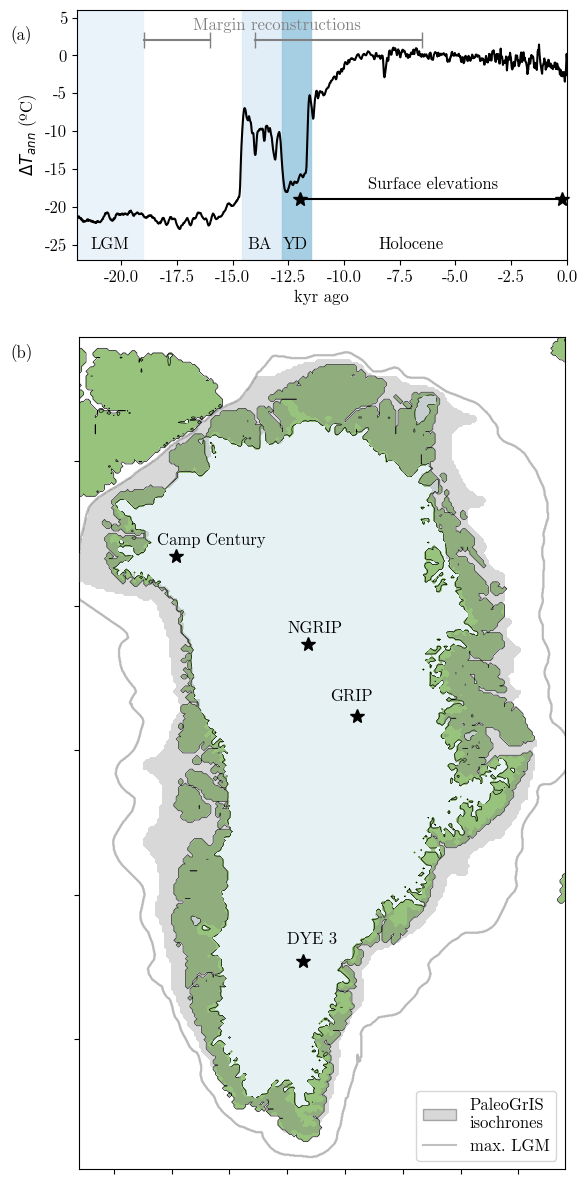

In [ ]:

fig, axs = plt.subplots(2,1, figsize=(6,12),gridspec_kw={"height_ratios": [3, 10]})

ax=axs[0]
ax.plot(-bui["NGRIP_Age "].values/1e3,bui["NGRIP_ANN"].values-bui["NGRIP_ANN"].values[0],color="black")
ax.set_xlim(-22,0)
ax.set_ylim(-27,6)
ax.set_xlabel("kyr ago")
ax.set_ylabel("$\Delta T_{ann}$ (ºC)")

ax.axvspan(-22, -19, color="#deebf7", alpha=0.6)
ax.axvspan(-19, -14.8, color="white", alpha=0.8)   # azul claro
ax.axvspan(-14.6, -12.8, color="#deebf7", alpha=0.9)   # azul muy claro
ax.axvspan(-12.8, -11.5, color="#9ecae1", alpha=0.9)   # azul algo más oscuro

ax.text(-20.5, -25, "LGM", ha="center", va="center")
ax.text(-13.8, -25, "BA",  ha="center", va="center")
ax.text(-12.2, -25, "YD",  ha="center", va="center")
ax.text(-7, -25, "Holocene",  ha="center", va="center")

ax.plot([-12, -0.2], [-19, -19], '-*k', markersize=10, clip_on=False)
ax.text(-6, -17, "Surface elevations", ha="center", va="center")

ax.plot([-14, -6.5], [2, 2], color="gray", linestyle="-", linewidth=1.5)
ax.plot([-14, -6.5], [2, 2], color="gray", marker="|", markersize=12, linestyle="")
ax.plot([-19, -16], [2, 2], color="gray", linestyle="-", linewidth=1.5)
ax.plot([-19, -16], [2, 2], color="gray", marker="|", markersize=12, linestyle="")
ax.text(-13, 4, "Margin reconstructions", ha="center", va="center", color="gray")

datos_tiempo = np.array(rsl.time.where(rsl.time < 20000)).flatten()/(-1000)
datos_tiempo = datos_tiempo[~np.isnan(datos_tiempo)]
datos_tiempo_reduced = datos_tiempo[::24]
y_base = -10

ax=axs[1]
add_map(ax, topo, gia, iso, rsl)

axs[0].text(-25,2,"(a)")
axs[0].text(-25,-40,"(b)")

plt.tight_layout(h_pad=-0.2)
fig.savefig("../figs/summary_records_2.png", dpi=300)
# plt.close()

<>:71: SyntaxWarning: invalid escape sequence '\D'
<>:71: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_164277/2491870261.py:71: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel("$\Delta \mathrm{T_{ann}}$ (ºC)")
/tmp/ipykernel_164277/2491870261.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, lim)


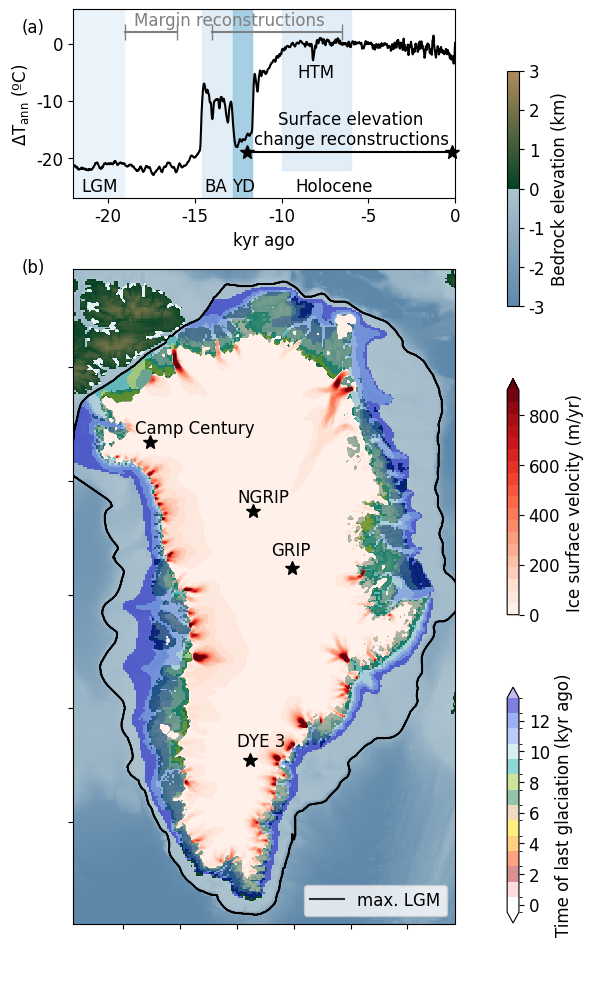

In [3]:
from matplotlib.colors import LightSource, TwoSlopeNorm
import matplotlib.gridspec as gridspec
def add_map2(ax, topo, iso, vel):
    lgm=xr.open_dataset("/p/projects/megarun/luciagu/data/leger2024/lgm.nc")
    lgm_leg = xr.where((lgm.mask==3)|(lgm.mask==2),1,0)
    # Fondo: Morlinghem et al. 2017
    ls = LightSource(azdeg=315, altdeg=45)
    zmap = mcolors.LinearSegmentedColormap.from_list("zmap", [
            (0.0, "#5E88AA"),
            (0.499, "#ADC3CF"),
            (0.50, "#024224"),
            (1.0, "#b18b5d")])
    norm = TwoSlopeNorm(vmin=topo.z_bed.min(), vcenter=0, vmax=topo.z_bed.max())
    rgb = ls.shade(topo.z_bed.values, cmap=zmap, norm=norm, blend_mode='soft', vert_exag=0.1)
    bat = ax.pcolormesh(topo.xc, topo.yc, topo.z_bed*1e-3, cmap=zmap, vmin=-3, vmax=3)
    img = ax.imshow(rgb, extent=[-5, 5, -5, 5])
    ax.contourf(topo.xc, topo.yc, topo.H_ice.where(topo.H_ice>10), levels=np.linspace(0,4000,2), colors="#E6F1F3",zorder=3)
    vels = ax.contourf(vel.xc, vel.yc, vel.uxy_srf.where(topo.H_ice>10), levels=np.linspace(0,900,20),cmap="Reds",extend="max",zorder=3)

    # Ice core locations
    for (lat,lon) in zip(icec[0,:], icec[1,:]):
        dist = np.sqrt((topo.lat2D - lat)**2 + (topo.lon2D - lon)**2)
        iy, ix = np.unravel_index(dist.argmin(), dist.shape)
        x = topo.xc[ix]
        y = topo.yc[iy]
        ax.plot(x, y, '*', color="black", markersize=10, markeredgecolor='black', zorder=6)  
    ax.text(-450,-1290,"Camp Century", fontsize=12)
    ax.text(0,-1595,"NGRIP", fontsize=12)
    ax.text(150,-1830,"GRIP", fontsize=12)
    ax.text(0,-2670,"DYE 3", fontsize=12)
    
    # Isochrones
    lim=14
    cmap_name =	cmaps.amwg_r
    cmap = cm.get_cmap(cmap_name, lim)
    colors = cmap(np.arange(cmap.N))
    colors[0] = [1, 1, 1, 1]
    cmap = mcolors.ListedColormap(colors)
    levels = np.linspace(-0.5, lim-0.5, lim+1)
    norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)
    im_iso = ax.pcolormesh(iso.xc,iso.yc,iso.age*1e-3, cmap=cmap, norm=norm, shading='auto',alpha=0.5)

    # lgm
    im_lgm=ax.contour(lgm.xc, lgm.yc, lgm_leg, colors='black',  alpha=0.8, linewidths=1)
    # Legend
    gia_lab = mlines.Line2D([], [],color='red',marker='o',markersize=8,markerfacecolor='red',markeredgecolor='black',linestyle='none', label="GPS stations")
    rsl_lab = mlines.Line2D([], [],color='pink',marker='^',markersize=8,markerfacecolor='pink',markeredgecolor='black',linestyle='none',label="RSL")
    lgm_lab = mlines.Line2D([], [],color='black',markerfacecolor='black',linestyle='solid',alpha=0.8,label="max. LGM")
    iso_lab = Rectangle((0,0), 1, 1,facecolor='gray',edgecolor='black',alpha=0.3,label='PaleoGrIS\nisochrones')
    ax.legend(handles=[lgm_lab],
                loc='lower right')
    ax.set_xlim(iso.xc.min(),iso.xc.max())
    ax.set_ylim(iso.yc.min(),iso.yc.max())
    ax.tick_params(labelbottom=False, labelleft=False)
    ax.set_aspect(1)

    return vels, bat, im_iso


fig = plt.figure(figsize=(6, 10))
gs = gridspec.GridSpec(4, 2, figure=fig, 
                       height_ratios=[0.8, 1, 1, 1], 
                       width_ratios=[4, 1])

ax = fig.add_subplot(gs[0, 0])

ax.plot(-bui["NGRIP_Age "].values/1e3,bui["NGRIP_ANN"].values-bui["NGRIP_ANN"].values[0],color="black")
ax.set_xlim(-22,0)
ax.set_ylim(-27,6)
ax.set_xlabel("kyr ago")
ax.set_ylabel("$\Delta \mathrm{T_{ann}}$ (ºC)")

ax.axvspan(-22, -19, color="#deebf7", alpha=0.6)
ax.axvspan(-19, -14.8, color="white", alpha=0.8)   # azul claro
ax.axvspan(-14.6, -12.8, color="#deebf7", alpha=0.9)   # azul muy claro
ax.axvspan(-12.8, -11.7, color="#9ecae1", alpha=0.9)   # azul algo más oscuro
ax.axvspan(-10, -6, ymin=0.15, ymax=1, color="#deebf7", alpha=0.9)   # azul muy claro

ax.text(-20.5, -25, "LGM", ha="center", va="center")
ax.text(-13.8, -25, "BA",  ha="center", va="center")
ax.text(-12.2, -25, "YD",  ha="center", va="center")
ax.text(-7, -25, "Holocene",  ha="center", va="center")
ax.text(-8, -5, "HTM",  ha="center", va="center")

ax.plot([-12, -0.2], [-19, -19], '-*k', markersize=10, clip_on=False)
ax.text(-6, -15, "Surface elevation\nchange reconstructions", ha="center", va="center")

ax.plot([-14, -6.5], [2, 2], color="gray", linestyle="-", linewidth=1.5)
ax.plot([-14, -6.5], [2, 2], color="gray", marker="|", markersize=12, linestyle="")
ax.plot([-19, -16], [2, 2], color="gray", linestyle="-", linewidth=1.5)
ax.plot([-19, -16], [2, 2], color="gray", marker="|", markersize=12, linestyle="")
ax.text(-13, 4, "Margin reconstructions", ha="center", va="center", color="gray")

datos_tiempo = np.array(rsl.time.where(rsl.time < 20000)).flatten()/(-1000)
datos_tiempo = datos_tiempo[~np.isnan(datos_tiempo)]
datos_tiempo_reduced = datos_tiempo[::24]
y_base = -10
ax.text(-25,2,"(a)")
ax.text(-25,-40,"(b)")

ax = fig.add_subplot(gs[1:4, 0])
vels, bat, im_iso = add_map2(ax, topo, iso, vel)

plt.tight_layout(h_pad=-0.4)
plt.subplots_adjust(hspace=0.1)

ax_bar1 = fig.add_subplot(gs[1, 1])
ax_bar2 = fig.add_subplot(gs[2, 1])
ax_bar3 = fig.add_subplot(gs[3, 1])
ax_bar1.axis('off')
ax_bar2.axis('off')
ax_bar3.axis('off')

cbar = plt.colorbar(bat, ax=ax_bar1, fraction=0.7, pad=0.04)
cbar.set_label('Bedrock elevation (km)')
pos = cbar.ax.get_position()
cbar.ax.set_position([pos.x0, pos.y0 + 0.15, pos.width, pos.height])

cbar = plt.colorbar(vels, ax=ax_bar2, fraction=0.7, pad=0.04, ticks=[0,200,400,600,800])
cbar.set_label('Ice surface velocity (m/yr)')
pos = cbar.ax.get_position()
cbar.ax.set_position([pos.x0, pos.y0 + 0.1, pos.width, pos.height])

cbar = plt.colorbar(im_iso, ax=ax_bar3, fraction=0.7, pad=0.04, ticks=[0,2,4,6,8,10,12,14],
                    extend="both")
cbar.set_label('Time of last glaciation (kyr ago)')
pos = cbar.ax.get_position()
cbar.ax.set_position([pos.x0, pos.y0 + 0.05, pos.width, pos.height])

fig.savefig("../figs_final/fig1_summary_records.png", dpi=300)
# plt.close()
